# Fase 4-B - Precursores do pico (ESTRITAMENTE ESTATISTICO)

**Objetivo 1:** que variaveis e lags precedem o aquecimento maximo da SST.

**Escopo (corrigido):** a Fase 4 e *exploratory_statistical_preanalysis*. Este
notebook usa **somente estatistica**: correlacao (Pearson/Spearman), correlacao
cruzada defasada, correlacao parcial, colinearidade (VIF + cluster), compositos
de evento com IC por bootstrap e regressao linear (OLS) **com inferencia**
(R2 ajustado, teste F, p-valores). **Nenhum metodo de machine learning** -
Random Forest, gradient boosting, ElasticNet e SHAP pertencem a Fase 5.

Toda tabela e impressa na tela e atribuida a uma variavel (`tab_*`); nada e
salvo em CSV.

In [1]:
from pathlib import Path
import sys, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT/'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT/'scripts'))
import fase4_features as F
plt.rcParams.update({'figure.dpi':110,'axes.grid':True,'grid.alpha':0.3,'font.size':9})

import re as _re
OUTB = F.STATS/'phase4_B_precursores'; OUTB.mkdir(parents=True, exist_ok=True)
def show(df, titulo):
    print('='*82); print(titulo); print('='*82); print(df.to_string()); print()
    slug = _re.split(r'\s+-\s+', titulo.strip())[0].strip().replace(' ','_')
    df.to_csv(OUTB/f'{slug}.csv'); print(f'[csv: phase4_B_precursores/{slug}.csv]\n')
    return df

def ols_inference(X, y, names):
    # OLS com intercepto: devolve tabela de coeficientes (coef,se,t,p), R2, R2aj, F
    X = np.asarray(X, float); y = np.asarray(y, float)
    X1 = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(X1, y, rcond=None)
    resid = y - X1@beta; n, p = X1.shape; dof = n - p
    sigma2 = (resid@resid)/dof
    XtXinv = np.linalg.pinv(X1.T@X1)  # pinv: robusto a colinearidade/singularidade
    se = np.sqrt(np.diag(sigma2*XtXinv)); tval = beta/se
    pval = 2*stats.t.sf(np.abs(tval), dof)
    ss_tot = ((y-y.mean())**2).sum(); ss_res = resid@resid
    r2 = 1 - ss_res/ss_tot; adj = 1 - (1-r2)*(n-1)/dof
    Fstat = ((ss_tot-ss_res)/(p-1))/(ss_res/dof)
    tab = pd.DataFrame({'coef':beta,'se':se,'t':tval,'p_valor':pval},
                       index=['intercepto']+list(names))
    return tab, r2, adj, Fstat

def partial_corr(x, y, z):
    # correlacao de x e y controlando z (resíduos de regressao em z)
    d = pd.concat([x.rename('x'), y.rename('y'), z], axis=1).dropna()
    Z = np.column_stack([np.ones(len(d)), d.iloc[:,2:].values])
    rx = d['x'].values - Z@np.linalg.lstsq(Z, d['x'].values, rcond=None)[0]
    ry = d['y'].values - Z@np.linalg.lstsq(Z, d['y'].values, rcond=None)[0]
    return float(np.corrcoef(rx, ry)[0,1]), len(d)

def vif(df, cols):
    out = {}
    for c in cols:
        others = [o for o in cols if o != c]
        d = df[[c]+others].dropna()
        if len(d) < 30 or not others: out[c] = np.nan; continue
        X = np.column_stack([np.ones(len(d)), d[others].values]); yv = d[c].values
        b, *_ = np.linalg.lstsq(X, yv, rcond=None); r = yv - X@b
        r2 = 1 - (r@r)/(((yv-yv.mean())**2).sum() or 1)
        out[c] = (1/(1-r2)) if r2 < 1 else np.inf
    return pd.Series(out, name='VIF')
print('helpers estatisticos prontos (OLS, correlacao parcial, VIF)')

helpers estatisticos prontos (OLS, correlacao parcial, VIF)


## 1. Matriz ampla + alvo (maximo futuro de SSTA)

Backbone (SST+oceano) + atmosfera ERA5. Alvo: maximo de SSTA nos proximos 150 d
(precursor do pico). `ATMO=False` para teste rapido.

In [2]:
ATMO = True
_pq = F.PROC/'parquet'/'modeling'/'phase4_feature_matrix_daily.parquet'
matrix = pd.read_parquet(_pq) if _pq.exists() else F.assemble_feature_matrix(years=range(1981,2026), atmosphere=ATMO, save=True)
print('matriz:', matrix.shape, '| fonte:', 'parquet cache' if _pq.exists() else 'rebuild')
def forward_max(s, H):
    v = s.to_numpy('float64'); n = len(v); out = np.full(n, np.nan)
    for i in range(n):
        j = min(n, i+1+H)
        if j > i+1 and np.isfinite(v[i+1:j]).any(): out[i] = np.nanmax(v[i+1:j])
    return pd.Series(out, index=s.index)
y_reg = forward_max(matrix['nino34_ssta'], 150)
print('alvo future_max_ssta_150d - validos:', int(y_reg.notna().sum()))

matriz: (16353, 285) | fonte: parquet cache
alvo future_max_ssta_150d - validos: 16352


## 2. Severidade p90/p95 (forca do sinal)

Percentis da SSTA: p90 = El Nino forte, p95 = extremo. Tabela e faixas no grafico.

tab_severidade - limiares e dias acima
     limiar_C  n_dias_acima
p90     1.128          1636
p95     1.626           818

[csv: phase4_B_precursores/tab_severidade.csv]



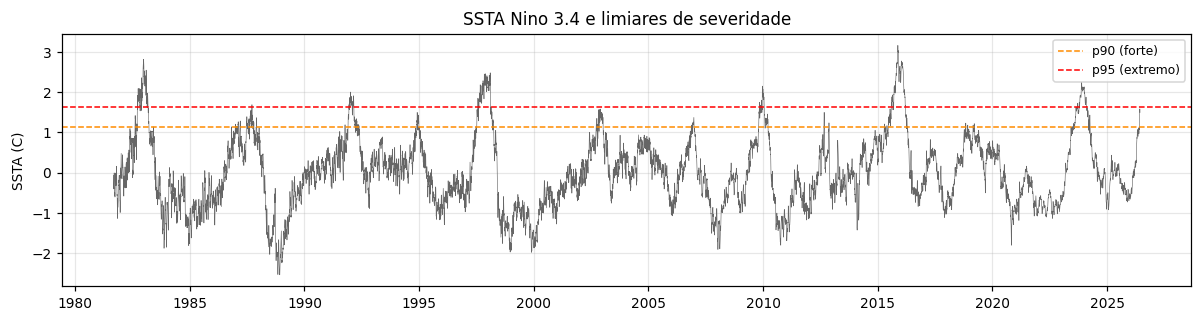

In [3]:
ssta = matrix['nino34_ssta']
th = F.daily_percentile_thresholds(ssta, qs=(0.90,0.95))
sev = F.severity_classify(ssta, th)
tab_severidade = pd.DataFrame({'limiar_C':[round(th[0.90],3), round(th[0.95],3)],
    'n_dias_acima':[int(sev.above_p90.sum()), int(sev.above_p95.sum())]}, index=['p90','p95'])
tab_severidade = show(tab_severidade, 'tab_severidade - limiares e dias acima')
fig, ax = plt.subplots(figsize=(11,3))
ax.plot(ssta.index, ssta.values, lw=0.4, color='0.4')
ax.axhline(th[0.90], color='darkorange', ls='--', lw=1, label='p90 (forte)')
ax.axhline(th[0.95], color='red', ls='--', lw=1, label='p95 (extremo)')
ax.legend(fontsize=8); ax.set_ylabel('SSTA (C)')
ax.set_title('SSTA Nino 3.4 e limiares de severidade', fontsize=11)
plt.tight_layout(); plt.show()

## 3. Estatistica descritiva das features-base

`tab_descritiva`: n, media, desvio, min/mediana/max e assimetria de cada
variavel-base candidata a preditor.

In [4]:
DROP = {'year','month','day','ocean_source_code','ocean_source_priority'}
import re
base_feats = [c for c in matrix.select_dtypes('number').columns
              if not re.search(r'_(mean|delta)_\d+d$', c) and c not in DROP]
d = matrix[base_feats]
tab_descritiva = pd.DataFrame({'n':d.notna().sum(),'media':d.mean().round(3),
    'desvio':d.std().round(3),'min':d.min().round(3),'mediana':d.median().round(3),
    'max':d.max().round(3),'assimetria':d.skew().round(2)})
tab_descritiva = show(tab_descritiva, 'tab_descritiva - estatistica descritiva das features-base')

tab_descritiva - estatistica descritiva das features-base
                                            n         media        desvio           min       mediana           max  assimetria
nino34_sst                              16353  2.697800e+01  9.980000e-01  2.403400e+01  2.700100e+01  2.981500e+01       -0.07
nino34_ssta                             16353 -0.000000e+00  8.770000e-01 -2.543000e+00 -6.800000e-02  3.164000e+00        0.44
d20_nino34_mean_m                       16353  1.278000e+02  1.516100e+01  8.009800e+01  1.277030e+02  1.627570e+02       -0.24
ohc_0_100_nino34_j_m2                   16353  1.066169e+10  4.862409e+08  9.231478e+09  1.066089e+10  1.201839e+10        0.03
ohc_0_300_nino34_j_m2                   16353  2.279102e+10  1.067541e+09  1.981132e+10  2.269550e+10  2.614598e+10        0.27
ohc_0_700_nino34_j_m2                   16353  3.650696e+10  1.240304e+09  3.319071e+10  3.641016e+10  4.047669e+10        0.26
ohc_300_700_nino34_j_m2                 16353 

## 4. Correlacao cruzada defasada (qual lag lidera o pico)

Para cada feature: lag de maior |correlacao| (Spearman) com o alvo. lag>0 =
a feature **antecede** o pico. `tab_best_lag` ordenada por forca.

tab_best_lag - melhor lag por feature (Spearman)
                                   feature             bloco  melhor_lag_dias   corr
20                  nino34_anom_3mo_mean_c             other                7  0.843
19                           nino34_anom_c               sst                7  0.831
1                              nino34_ssta               sst                7  0.809
3                    ohc_0_100_nino34_j_m2        ocean_heat                7  0.799
14                temperature_50m_nino34_c        ocean_heat                7  0.761
0                               nino34_sst               sst                7  0.706
4                    ohc_0_300_nino34_j_m2        ocean_heat               35  0.694
7                        ssh_nino34_mean_m         sea_level               14  0.660
9                temperature_100m_nino34_c        ocean_heat               35  0.647
5                    ohc_0_700_nino34_j_m2        ocean_heat               35  0.634
21       nino34_

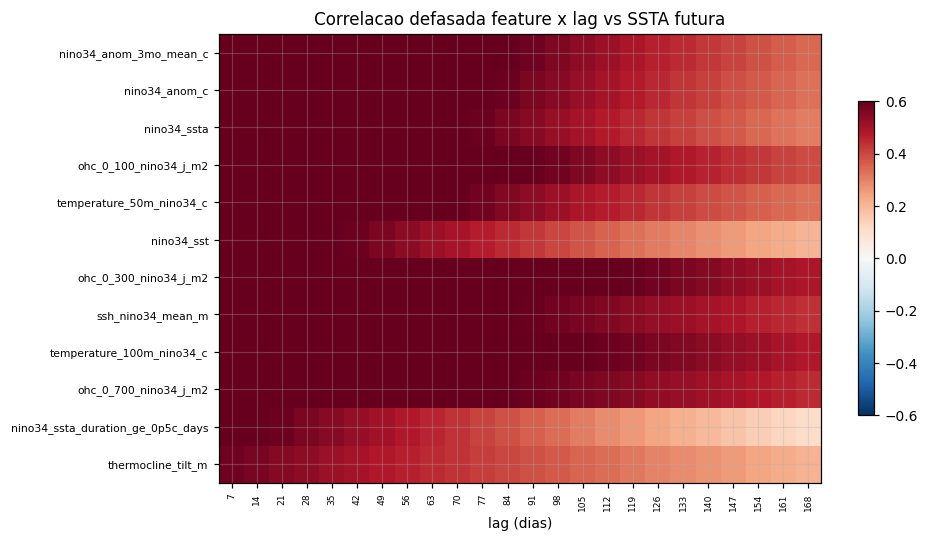

In [5]:
rows = []
for c in base_feats:
    lc = F.lagged_correlation(matrix[c], y_reg, lags=F.LAGS, method='spearman')
    if lc['corr'].notna().any():
        b = lc.loc[lc['corr'].abs().idxmax()]
        rows.append((c, F.assign_block(c), int(b['lag']), round(float(b['corr']),3)))
tab_best_lag = pd.DataFrame(rows, columns=['feature','bloco','melhor_lag_dias','corr']).\
    sort_values('corr', key=lambda s: s.abs(), ascending=False)
tab_best_lag = show(tab_best_lag.head(25), 'tab_best_lag - melhor lag por feature (Spearman)')
top = tab_best_lag.head(12)['feature'].tolist()
H = np.array([F.lagged_correlation(matrix[c], y_reg, lags=F.LAGS)['corr'].values for c in top])
fig, ax = plt.subplots(figsize=(9,5))
im = ax.imshow(H, aspect='auto', cmap='RdBu_r', vmin=-0.6, vmax=0.6)
ax.set_xticks(range(len(F.LAGS))); ax.set_xticklabels(F.LAGS, rotation=90, fontsize=6)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top, fontsize=7)
ax.set_xlabel('lag (dias)'); ax.set_title('Correlacao defasada feature x lag vs SSTA futura', fontsize=11)
fig.colorbar(im, ax=ax, shrink=0.7); plt.tight_layout(); plt.show()

## 5. Correlacao parcial (precursor alem da persistencia)

Controla a SSTA **atual**: mede se a feature ainda correlaciona com o pico
futuro *depois* de descontar a persistencia da SSTA. So sobra o que e
genuinamente precursor. `tab_parcial`.

In [6]:
rows = []
ctrl = matrix[['nino34_ssta']]
for c in base_feats:
    if c == 'nino34_ssta': continue
    try:
        r_simple = matrix[c].corr(y_reg, method='spearman')
        r_part, n = partial_corr(matrix[c], y_reg, ctrl)
        rows.append((c, F.assign_block(c), round(float(r_simple),3), round(r_part,3)))
    except Exception: pass
tab_parcial = pd.DataFrame(rows, columns=['feature','bloco','corr_simples','corr_parcial_dado_SSTA']).\
    sort_values('corr_parcial_dado_SSTA', key=lambda s: s.abs(), ascending=False)
tab_parcial = show(tab_parcial.head(20), 'tab_parcial - correlacao parcial controlando SSTA atual')

tab_parcial - correlacao parcial controlando SSTA atual
                                feature       bloco  corr_simples  corr_parcial_dado_SSTA
19               nino34_anom_3mo_mean_c       other         0.861                   0.404
18                        nino34_anom_c         sst         0.850                   0.333
3                 ohc_0_300_nino34_j_m2  ocean_heat         0.680                   0.314
1                     d20_nino34_mean_m  ocean_heat         0.475                   0.305
8             temperature_100m_nino34_c  ocean_heat         0.626                   0.302
2                 ohc_0_100_nino34_j_m2  ocean_heat         0.808                   0.302
6                     ssh_nino34_mean_m   sea_level         0.658                   0.279
9             temperature_150m_nino34_c  ocean_heat         0.371                   0.278
4                 ohc_0_700_nino34_j_m2  ocean_heat         0.621                   0.253
17            wwv_equatorial_pacific_m3  oce

## 6. Colinearidade por bloco (cluster + VIF)

Reduz redundancia (OHC/temperaturas/D20/WWV medem quase o mesmo calor):
1 representante por cluster, e VIF dos representantes. `tab_vif`, `tab_clusters`.

In [7]:
kept, mapping = F.reduce_collinearity_by_block(matrix, base_feats, threshold=0.9, target=y_reg)
tab_clusters = show(mapping.groupby('block')['feature'].count().rename('n_no_bloco').to_frame(),
                    'tab_clusters - n de features por bloco antes da reducao')
print('representantes mantidos:', len(kept), 'de', len(base_feats), '\n')
dd = matrix[kept].dropna()
tab_vif = vif(dd, kept).round(2).sort_values(ascending=False).to_frame()
tab_vif = show(tab_vif, 'tab_vif - fator de inflacao de variancia dos representantes')

tab_clusters - n de features por bloco antes da reducao
                  n_no_bloco
block                       
convection                 7
heat_flux                  4
ocean_heat                13
other                      1
pressure                   3
salinity                   1
sea_level                  1
sst                        6
thermocline_tilt           2
wind                       6

[csv: phase4_B_precursores/tab_clusters.csv]

representantes mantidos: 36 de 44 

tab_vif - fator de inflacao de variancia dos representantes
                                          VIF
d20_nino34_mean_m                       24.50
temperature_200m_nino34_c                8.62
atm_total_column_water_vapour_anom       8.46
ssh_nino34_mean_m                        5.51
nino34_anom_c                            4.87
nino34_anom_3mo_mean_c                   4.85
nino34_sst                               4.67
temperature_300m_nino34_c                4.63
ohc_0_300_nino34_j_m2                  

## 7. Compositos de evento com IC bootstrap

Alinha os eventos El Nino pelo `peak_time` e mostra a anomalia media de cada
precursor em t-360..t+30 d, com **intervalo de confianca 90% por bootstrap**
entre eventos - a sequencia fisica que antecede o pico, com incerteza.

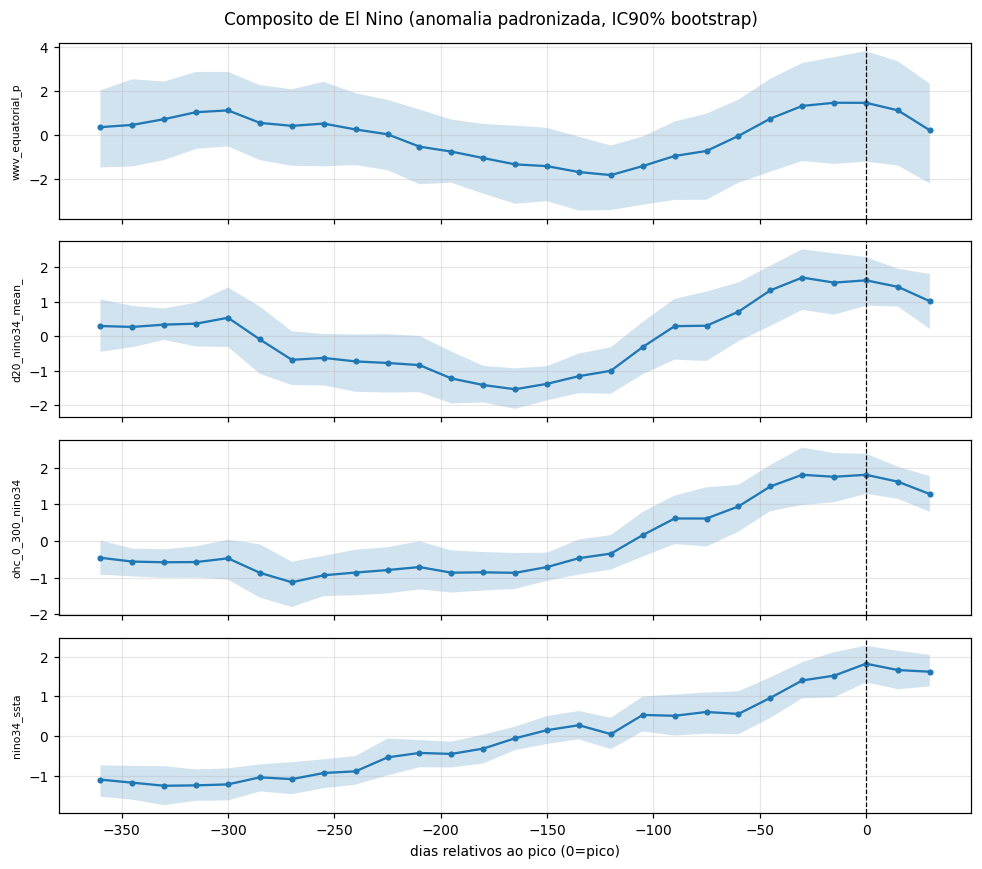

In [8]:
peaks = pd.read_csv(F.PEAK_CSV)
tcol = next((c for c in peaks.columns if 'peak_time' in c), None)
peaks[tcol] = pd.to_datetime(peaks[tcol], errors='coerce')
ev = peaks.dropna(subset=[tcol])
if 'peak_class' in ev.columns:
    ev = ev[ev['peak_class'].astype(str).str.contains('nino', case=False, na=False)]
pk = ev[tcol].tolist()
showvars = [v for v in ['wwv_equatorial_pacific_m3','d20_nino34_mean_m','ohc_0_300_nino34_j_m2','nino34_ssta'] if v in matrix]
offsets = np.arange(-360, 31, 15)
fig, axes = plt.subplots(len(showvars), 1, figsize=(9, 2.0*len(showvars)), sharex=True)
for ax, var in zip(np.atleast_1d(axes), showvars):
    s = matrix[var]; M = []
    for off in offsets:
        vals = np.array([s.asof(pd.Timestamp(p)+pd.Timedelta(days=int(off))) for p in pk], float)
        vals = vals[np.isfinite(vals)]
        boot = [np.mean(np.random.choice(vals, len(vals), replace=True)) for _ in range(500)] if len(vals)>2 else [np.nan]
        M.append((np.mean(vals) if len(vals) else np.nan, np.percentile(boot,5), np.percentile(boot,95)))
    M = np.array(M); mu=(M[:,0]-np.nanmean(M[:,0]))/(np.nanstd(M[:,0])+1e-9)
    sc = (np.nanstd(M[:,0])+1e-9)
    ax.plot(offsets, mu, marker='o', ms=3)
    ax.fill_between(offsets, (M[:,1]-np.nanmean(M[:,0]))/sc, (M[:,2]-np.nanmean(M[:,0]))/sc, alpha=0.2)
    ax.axvline(0, color='k', ls='--', lw=0.8); ax.set_ylabel(var[:16], fontsize=7)
axes[-1].set_xlabel('dias relativos ao pico (0=pico)')
fig.suptitle('Composito de El Nino (anomalia padronizada, IC90% bootstrap)', fontsize=11)
plt.tight_layout(); plt.show()

## 8. Regressao OLS incremental por bloco (com inferencia)

Adiciona blocos fisicos um a um e mede o **R2 ajustado** fora-da-amostra-nao,
mas com inferencia classica (R2aj penaliza variaveis inuteis; teste F).
`tab_incremental` mostra o ganho de cada bloco; `tab_ols_final` os coeficientes
com p-valor. Isto e estatistica (OLS), nao machine learning.

In [9]:
blocks_order = ['sst','ocean_heat','thermocline_tilt','sea_level','salinity','wind','pressure','convection','heat_flux']
def cols_of(blks): return [c for c in kept if F.assign_block(c) in blks]
dfm = matrix[kept].copy(); dfm['__y'] = y_reg
dfm = dfm.dropna()
# padroniza (z-score global) so para comparar coeficientes
Z = (dfm[kept]-dfm[kept].mean())/dfm[kept].std(ddof=0)
rows = []; acc = []
for b in blocks_order:
    acc.append(b); cs = cols_of(acc)
    if not cs: continue
    _, r2, adj, Fst = ols_inference(Z[cs].values, dfm['__y'].values, cs)
    rows.append(('+'.join(acc), len(cs), round(r2,3), round(adj,3), round(Fst,1)))
tab_incremental = pd.DataFrame(rows, columns=['blocos','n_feat','R2','R2_ajustado','F'])
tab_incremental = show(tab_incremental, 'tab_incremental - ganho de R2 ajustado por bloco (OLS)')
tab_ols_final, r2, adj, Fst = ols_inference(Z[kept].values, dfm['__y'].values, kept)
tab_ols_final = show(tab_ols_final.round(4).sort_values('p_valor'),
                     f'tab_ols_final - coeficientes OLS (R2={r2:.3f}, R2aj={adj:.3f}, F={Fst:.1f})')

tab_incremental - ganho de R2 ajustado por bloco (OLS)
                                                                                  blocos  n_feat     R2  R2_ajustado       F
0                                                                                    sst       5  0.750        0.750  9717.7
1                                                                         sst+ocean_heat      13  0.788        0.788  4638.5
2                                                        sst+ocean_heat+thermocline_tilt      15  0.795        0.795  4177.0
3                                              sst+ocean_heat+thermocline_tilt+sea_level      16  0.797        0.797  3975.9
4                                     sst+ocean_heat+thermocline_tilt+sea_level+salinity      17  0.797        0.797  3743.6
5                                sst+ocean_heat+thermocline_tilt+sea_level+salinity+wind      22  0.802        0.801  2968.2
6                       sst+ocean_heat+thermocline_tilt+sea_level+sali

## Interpretacao (Objetivo 1, estatistico)

- `tab_best_lag` / heatmap: qual variavel e em que lag antecipa o pico.
- `tab_parcial`: o que ainda preve o pico **alem** da persistencia da SSTA -
  os precursores genuinos (tipicamente WWV/D20/OHC).
- `tab_vif`/`tab_clusters`: redundancia tratada por bloco fisico.
- Composito: a sequencia fisica (recarga oceanica -> aquecimento) com incerteza.
- `tab_incremental`/`tab_ols_final`: contribuicao de cada bloco por R2 ajustado
  e significancia (p-valor) - inferencia estatistica, sem ML.

Modelagem preditiva (RF/boosting/SHAP) fica para a **Fase 5**.